# B-factor analysis.

In [1]:
import  numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.stats

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

cm = 1/2.54  # centimeters in inches
colors = ["#F9D9D8", "#EDA3B2", "#7E73AC"]

In [2]:
import MDAnalysis as mda
from MDAnalysis.analysis import align, rms

def get_exp_bfactors(cif: str) -> tuple[np.ndarray, np.ndarray]:
  resids, b_factors = [], []
  with open(cif, 'r') as f:
    lines = [line for line in f.readlines() if line.startswith('ATOM')]
    for line in lines:
      if line[13:15]=='CA':
        resids.append(int(line[27:29]))
        b_factors.append(float(line[58:64]))
  return np.asarray(resids), np.asarray(b_factors)

def get_sim_bfactors(top: str, dcd: str) -> tuple[np.ndarray, np.ndarray]: 
  c_alphas = 'protein and name CA'
  u = mda.Universe(top, dcd, topology_format=top[-3:])
  ref = align.AverageStructure(u, u, select=c_alphas, ref_frame=0).run().results.universe
  align.AlignTraj(u, ref, select=c_alphas, in_memory=True).run()
  rmsf = rms.RMSF(u.select_atoms(c_alphas)).run()
  b_factors = 8. * (np.pi**2) / 3. * (np.asarray(rmsf.results.rmsf)**2)
  return u.select_atoms(c_alphas).resids, b_factors  

exp_resids, exp_bfactor = get_exp_bfactors(cif='./test0_ubq/1ubq.cif')
sim_resids, sim_bfactor = get_sim_bfactors(top='./test0_ubq/aftools_runtime/afre/init_results.pdb',
                                           dcd='./test0_ubq/aftools_runtime/afre/afre_traj.dcd', )
md_resids, md_bfactor = get_sim_bfactors(top='./test0_ubq/ubq_bfactor/md_traj.psf', 
                                         dcd='./test0_ubq/ubq_bfactor/md_traj.dcd', )
assert (exp_resids==sim_resids).all()

/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


5.999999999999999 4.25
0.45840648664458455
0.49491052539729263
0.46877192982456145
0.43679064010865887 (72,)


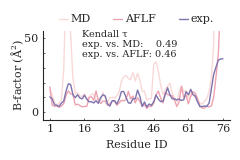

In [10]:
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  19/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1  *cm,
          'vsize':   9/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(1, 1, figsize=figsize, sharey=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

axes.plot(exp_resids,  md_bfactor, ls='-', lw=1, c=colors[0], label='MD')
axes.plot(exp_resids, sim_bfactor, ls='-', lw=1, c=colors[1], label='AFLF')
axes.plot(exp_resids, exp_bfactor, ls='-', lw=1, c=colors[2], label='exp.')
axes.text(15, 50., f"Kendall τ", ha='left', va='bottom', fontsize=7)
axes.text(15, 43., f"exp. vs. MD:    {scipy.stats.kendalltau(exp_bfactor, md_bfactor)[0]:.2f}", ha='left', va='bottom', fontsize=7)
axes.text(15, 36., f"exp. vs. AFLF: {scipy.stats.kendalltau(exp_bfactor, sim_bfactor)[0]:.2f}", ha='left', va='bottom', fontsize=7)
axes.legend(loc='upper center', ncol=3, handletextpad=0.3, prop={'size': 8}, handlelength=0.8, frameon=False, bbox_to_anchor=(0.5, 1.3))
axes.set(ylim=(-5, 55), 
         yticks=list(range(0, 51, 10)), 
         yticklabels=['0', '', '', '', '', '50'],
         xlim=(-2, 79), 
         xticks=(1, 16, 31, 46, 61, 76, ))
axes.set_ylabel(r'B-factor (Å$^2$)', fontsize=8, va='center')
axes.set_xlabel(r'Residue ID', fontsize=8, ha='center')

axes.minorticks_off()
axes.spines[['top','right']].set_visible(False)
axes.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
plt.savefig(f'./zfigures/fig_bfactor_ubq.jpg', dpi=300)

print(scipy.stats.kendalltau(exp_bfactor, sim_bfactor)[0])
# print(scipy.stats.kendalltau(exp_bfactor, sim_bfactor)[0])
print(scipy.stats.kendalltau(exp_bfactor,  md_bfactor)[0])
print(scipy.stats.kendalltau(sim_bfactor,  md_bfactor)[0])
print(scipy.stats.kendalltau(exp_bfactor[:72],  md_bfactor[:72])[0], exp_bfactor[:72].shape)

In [4]:

u = mda.Universe(f'./test0_ubq/aftools_runtime/afre/init_results.pdb')
u.add_TopologyAttr('tempfactors')
protein = u.select_atoms('protein') # select protein atoms
for residue, bfactor in zip(protein.residues, sim_bfactor):
    residue.atoms.tempfactors = bfactor
u.atoms.write('./zpdbs/fig_bfactor_ubq_aflf.pdb')
for residue, bfactor in zip(protein.residues, exp_bfactor):
    residue.atoms.tempfactors = bfactor
u.atoms.write('./zpdbs/fig_bfactor_ubq_exp.pdb')
for id, (residue, e, md, s) in enumerate(zip(u.residues, exp_bfactor, md_bfactor, sim_bfactor)):
    print(residue.resname, id+1, f'{e:.2f}', f'{md:.2f}', f'{s:.2f}')

MET 1 10.38 15.32 17.17
GLN 2 9.07 11.58 4.85
ILE 3 5.07 6.66 3.92
PHE 4 4.68 5.00 4.35
VAL 5 3.87 5.69 3.29
LYS 6 6.12 8.47 4.18
THR 7 7.48 28.25 5.76
LEU 8 14.15 85.86 11.23
THR 9 19.24 84.06 14.41
GLY 10 18.74 52.76 12.40
LYS 11 11.91 23.08 12.07
THR 12 9.85 12.51 5.01
ILE 13 11.84 13.33 5.40
THR 14 9.63 11.06 4.55
LEU 15 9.03 10.59 3.63
GLU 16 11.50 12.44 3.87
VAL 17 8.85 8.60 3.95
GLU 18 7.08 10.28 9.98
PRO 19 7.07 12.03 10.43
SER 20 6.28 12.20 7.98
ASP 21 7.70 8.06 14.38
THR 22 6.01 8.86 7.88
ILE 23 9.92 7.75 5.91
GLU 24 11.81 13.49 7.39
ASN 25 10.96 9.66 7.53
VAL 26 5.53 6.92 4.69
LYS 27 4.14 9.86 5.84
ALA 28 7.74 10.05 7.49
LYS 29 7.90 9.63 7.53
ILE 30 5.58 10.96 4.71
GLN 31 8.67 13.75 6.24
ASP 32 14.01 20.86 8.09
LYS 33 14.00 24.20 7.61
GLU 34 10.07 24.75 8.71
GLY 35 6.29 22.87 14.10
ILE 36 6.07 22.02 8.99
PRO 37 9.18 26.91 10.99
PRO 38 9.08 21.09 6.39
ASP 39 14.96 26.34 9.83
GLN 40 10.76 21.56 7.19
GLN 41 3.87 14.06 4.10
ARG 42 6.97 14.19 5.06
LEU 43 3.51 8.21 2.54
ILE 44 5.5

/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/home/songzl/software/miniconda3/envs/openmm/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


2.25 1.7499999999999998


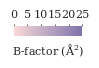

In [5]:
figspec= {'lmargin': 1/4*cm, 
          'rmargin': 1/4*cm,
          'hgap':    0  *cm,
          'hsize':   7/4*cm,
          'bmargin': 3/4*cm,
          'tmargin': 3/4*cm,
          'vgap':    0  *cm,
          'vsize':   1/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(1, 1, figsize=figsize, sharey=True, 
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

cmap = LinearSegmentedColormap.from_list('two_tone', [colors[0], colors[2]])
norm = plt.Normalize(vmin=0., vmax=25)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=axes, orientation='horizontal')
cbar.ax.set_xticks([0., 5, 10, 15, 20, 25])
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.tick_params(axis='x', direction='out', length=1.5, width=.5, labelsize=8)
for spine in cbar.ax.spines.values():
    spine.set_visible(False)
cbar.set_label(r'B-factor (Å$^2$)')

plt.savefig(f'./zfigures/fig_bfactor_ubq.cbar.jpg', dpi=300)